# 02 Behavioral Exploratory Data Analysis

This notebook explores early player behavior patterns in the Phasmophobia Steam review dataset.

The goal is not to finalize the model or dashboard yet.  
The goal is to understand what kinds of behavioral signals appear before manual tagging.

Main exploratory questions:

- Are `Recommended` and `Not Recommended` reviews distributed evenly?
- Do high-playtime or veteran players behave differently?
- Are negative reviews longer or more detailed?
- Do update, bug, degradation, and emotional keywords appear more often in negative reviews?
- Are there early signs of mismatch, where the Steam label is positive but the text sounds mixed or complaint-heavy?
- Which reviews should be exported as candidates for manual tagging?

## 1. Load the pilot processed dataset

This notebook belongs to the early behavioral EDA stage.

The source file has been moved from `data/processed/` into `data/archive/` because it comes from the earlier processed dataset version.  
The notebook still uses it intentionally so the original sequential process is preserved.

Only the folder route is changed here.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_colwidth', 300)

DATA_ARCHIVE = Path('../data/archive')
DATA_INTERIM = Path('../data/interim')

DATA_PATH = DATA_ARCHIVE / 'phasmophobia_reviews_processed.csv'

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (40, 19)


,game_title,author_name,review_date,recommendation,playtime_raw,playtime_hours,review_length,helpful_text,review_text,cleaned_review,helpful_count,funny_count,word_count,char_count,contains_update_keyword,contains_bug_keyword,contains_emotional_keyword,is_veteran,playtime_segment
0,Phasmophobia,𝓜𝓸𝓷𝓼𝓽𝓮𝓻,Posted: 12 May,Recommended,5.3 hrs on record,5.3,58,No one has rated this review as helpful yet 0,Posted: 12 May\nEARLY ACCESS REVIEW\nYou can roast the ghost,You can roast the ghost,0,0,5,23,False,False,False,False,New
1,Phasmophobia,Oyster,Posted: 12 May,Recommended,72.7 hrs on record,72.7,119,No one has rated this review as helpful yet 0,Posted: 12 May\nEARLY ACCESS REVIEW\nits an alright game but for me its too clumsy and a bit glitchy so i rarely play it.,its an alright game but for me its too clumsy and a bit glitchy so i rarely play it.,0,0,19,84,False,True,False,False,Regular
2,Phasmophobia,Clown,Posted: 12 May,Not Recommended,77.1 hrs on record,77.1,124,No one has rated this review as helpful yet 0,Posted: 12 May\nEARLY ACCESS REVIEW\nRushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.,Rushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.,0,0,17,89,True,True,False,False,Regular
3,Phasmophobia,Kylie,Posted: 12 May,Recommended,44.1 hrs on record,44.1,132,No one has rated this review as helpful yet 0,Posted: 12 May\nEARLY ACCESS REVIEW\nI'm a lot less than just cleaning supplies and a lifeless bimbo body placed under a fabulous wig.,I'm a lot less than just cleaning supplies and a lifeless bimbo body placed under a fabulous wig.,0,0,18,97,False,False,False,False,Casual
4,Phasmophobia,HowdMyDikTzt,Posted: 12 May,Recommended,17.5 hrs on record,17.5,166,No one has rated this review as helpful yet 0,"Posted: 12 May\nEARLY ACCESS REVIEW\nOne of the best games i've played in a while. it scratches that curious itch for the unknown, and its fun to play when you're bored","One of the best games i've played in a while. it scratches that curious itch for the unknown, and its fun to play when you're bored",0,0,26,131,False,False,True,False,Casual


## 2. Prepare analysis-ready review text

Before doing EDA, the review text is cleaned again for analysis.

This step removes leftover metadata, normalizes whitespace, removes empty reviews, recomputes review length features, and creates `log_playtime` so skewed playtime values are easier to inspect.

In [41]:
# Create analysis-ready columns for cleaner EDA.
required_columns = [
    'recommendation',
    'cleaned_review',
    'playtime_hours',
    'helpful_count',
    'funny_count'
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df['cleaned_review'] = df['cleaned_review'].fillna('').astype(str)

def clean_for_analysis(text):
    text = str(text)

    # Remove residual Steam metadata that may still survive preprocessing
    text = re.sub(r'Product refunded\s*', '', text, flags=re.IGNORECASE)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['analysis_review'] = df['cleaned_review'].apply(clean_for_analysis)

# Remove empty reviews for EDA/modeling readiness
before_rows = len(df)
df = df[df['analysis_review'].str.strip() != ''].copy()
after_rows = len(df)

print(f"Removed empty reviews: {before_rows - after_rows}")
print(f"Remaining reviews: {after_rows}")

# Recompute text length features using analysis_review
df['word_count'] = df['analysis_review'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['analysis_review'].apply(lambda x: len(str(x)))

# Make sure numeric columns are numeric
for col in ['playtime_hours', 'helpful_count', 'funny_count', 'word_count', 'char_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Create log playtime for skewed Steam playtime data
df['log_playtime'] = np.log1p(df['playtime_hours'])

df.head()

Removed empty reviews: 1
Remaining reviews: 39


,game_title,author_name,review_date,recommendation,playtime_raw,playtime_hours,review_length,helpful_text,review_text,cleaned_review,...,funny_count,word_count,char_count,contains_update_keyword,contains_bug_keyword,contains_emotional_keyword,is_veteran,playtime_segment,analysis_review,log_playtime
0,Phasmophobia,𝓜𝓸𝓷𝓼𝓽𝓮𝓻,Posted: 12 May,Recommended,5.3 hrs on record,5.3,58,No one has rated this review as helpful yet 0,Posted: 12 May\nEARLY ACCESS REVIEW\nYou can roast the ghost,You can roast the ghost,...,0,5,23,False,False,False,False,New,You can roast the ghost,1.840550
1,Phasmophobia,Oyster,Posted: 12 May,Recommended,72.7 hrs on record,72.7,119,No one has rated this review as helpful yet 0,Posted: 12 May\nEARLY ACCESS REVIEW\nits an alright game but for me its too clumsy and a bit glitchy so i rarely play it.,its an alright game but for me its too clumsy and a bit glitchy so i rarely play it.,...,0,19,84,False,True,False,False,Regular,its an alright game but for me its too clumsy and a bit glitchy so i rarely play it.,4.300003
2,Phasmophobia,Clown,Posted: 12 May,Not Recommended,77.1 hrs on record,77.1,124,No one has rated this review as helpful yet 0,Posted: 12 May\nEARLY ACCESS REVIEW\nRushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.,Rushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.,...,0,17,89,True,True,False,False,Regular,Rushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.,4.357990
3,Phasmophobia,Kylie,Posted: 12 May,Recommended,44.1 hrs on record,44.1,132,No one has rated this review as helpful yet 0,Posted: 12 May\nEARLY ACCESS REVIEW\nI'm a lot less than just cleaning supplies and a lifeless bimbo body placed under a fabulous wig.,I'm a lot less than just cleaning supplies and a lifeless bimbo body placed under a fabulous wig.,...,0,18,97,False,False,False,False,Casual,I'm a lot less than just cleaning supplies and a lifeless bimbo body placed under a fabulous wig.,3.808882
4,Phasmophobia,HowdMyDikTzt,Posted: 12 May,Recommended,17.5 hrs on record,17.5,166,No one has rated this review as helpful yet 0,"Posted: 12 May\nEARLY ACCESS REVIEW\nOne of the best games i've played in a while. it scratches that curious itch for the unknown, and its fun to play when you're bored","One of the best games i've played in a while. it scratches that curious itch for the unknown, and its fun to play when you're bored",...,0,26,131,False,False,True,False,Casual,"One of the best games i've played in a while. it scratches that curious itch for the unknown, and its fun to play when you're bored",2.917771


## 3. Check the basic dataset profile

Before looking for deeper behavioral patterns, I first check the dataset size, missing values, data types, and basic numeric statistics.

This helps catch obvious issues before interpreting any charts.

In [42]:
# Dataset overview
print(f"Total Reviews After Hygiene: {len(df)}")

print("\n--- Missing Values ---")
display(df.isnull().sum())

print("\n--- Data Types ---")
df.info()

print("\n--- Descriptive Statistics ---")
display(
    df[
        [
            'playtime_hours',
            'word_count',
            'char_count',
            'helpful_count',
            'funny_count'
        ]
    ].describe()
)

Total Reviews After Hygiene: 39

--- Missing Values ---


game_title                    0
author_name                   0
review_date                   0
recommendation                0
playtime_raw                  0
playtime_hours                0
review_length                 0
helpful_text                  0
review_text                   0
cleaned_review                0
helpful_count                 0
funny_count                   0
word_count                    0
char_count                    0
contains_update_keyword       0
contains_bug_keyword          0
contains_emotional_keyword    0
is_veteran                    0
playtime_segment              0
analysis_review               0
log_playtime                  0
dtype: int64


--- Data Types ---
<class 'pandas.DataFrame'>
Index: 39 entries, 0 to 39
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   game_title                  39 non-null     str    
 1   author_name                 39 non-null     str    
 2   review_date                 39 non-null     str    
 3   recommendation              39 non-null     str    
 4   playtime_raw                39 non-null     str    
 5   playtime_hours              39 non-null     float64
 6   review_length               39 non-null     int64  
 7   helpful_text                39 non-null     str    
 8   review_text                 39 non-null     str    
 9   cleaned_review              39 non-null     str    
 10  helpful_count               39 non-null     int64  
 11  funny_count                 39 non-null     int64  
 12  word_count                  39 non-null     int64  
 13  char_count                  39 no

,playtime_hours,word_count,char_count,helpful_count,funny_count
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,143.343590,70.692308,388.897436,1.461538,0.102564
std,184.487325,117.714229,671.106266,2.532381,0.307355
min,1.900000,1.000000,2.000000,0.000000,0.000000
25%,30.400000,6.000000,26.500000,0.000000,0.000000
50%,59.700000,18.000000,97.000000,0.000000,0.000000
75%,189.200000,59.500000,343.500000,2.500000,0.000000
max,777.700000,490.000000,2974.000000,11.000000,1.000000


## 4. Recommendation distribution

This section checks the balance between `Recommended` and `Not Recommended` reviews.

The distribution matters because later findings can be biased if one recommendation class dominates the sample.

Counts:


recommendation
Recommended        21
Not Recommended    18
Name: count, dtype: int64


Percent:


recommendation
Recommended        53.85
Not Recommended    46.15
Name: proportion, dtype: float64

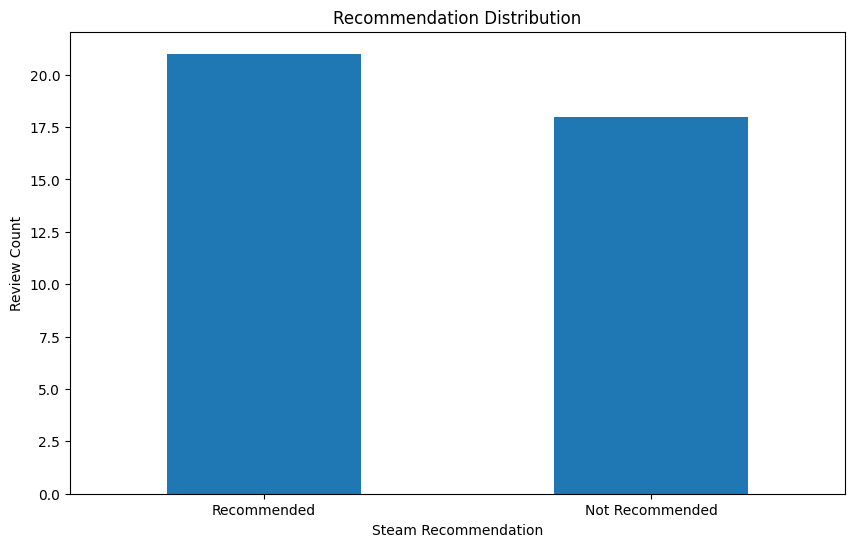

In [43]:
# Recommendation distribution

recommendation_counts = (
    df['recommendation']
    .value_counts()
)

recommendation_percent = (
    df['recommendation']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Counts:")
display(recommendation_counts)

print("\nPercent:")
display(recommendation_percent)

recommendation_counts.plot(
    kind='bar'
)

plt.title('Recommendation Distribution')
plt.ylabel('Review Count')
plt.xlabel('Steam Recommendation')
plt.xticks(rotation=0)
plt.show()

## 5. Playtime distribution

Steam playtime is usually skewed because a few players may have very high hours.

Using `log_playtime` makes it easier to compare whether `Recommended` and `Not Recommended` reviews come from different experience levels.

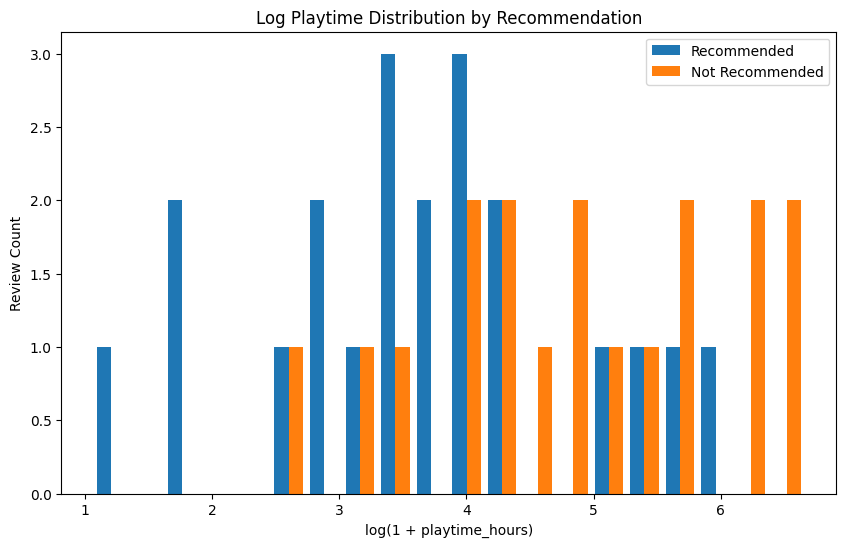

Median playtime by recommendation:


recommendation
Not Recommended    125.85
Recommended         37.10
Name: playtime_hours, dtype: float64


Playtime descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
recommendation,,,,,,,,
Not Recommended,18.0,218.583333,226.091765,11.3,53.85,125.85,278.3,777.7
Recommended,21.0,78.852381,108.423875,1.9,17.50,37.10,69.1,425.4


In [44]:
# Inspect log-transformed playtime by recommendation.

recommended_playtime = df[
    df['recommendation'] == 'Recommended'
]['log_playtime']

not_recommended_playtime = df[
    df['recommendation'] == 'Not Recommended'
]['log_playtime']

plt.hist(
    [
        recommended_playtime,
        not_recommended_playtime
    ],
    bins=20,
    label=[
        'Recommended',
        'Not Recommended'
    ]
)

plt.legend()
plt.title('Log Playtime Distribution by Recommendation')
plt.xlabel('log(1 + playtime_hours)')
plt.ylabel('Review Count')
plt.show()

print("Median playtime by recommendation:")
display(
    df.groupby('recommendation')['playtime_hours']
    .median()
)

print("\nPlaytime descriptive statistics:")
display(
    df.groupby('recommendation')['playtime_hours']
    .describe()
)

## 6. Player segment analysis

Here, the main question is whether veteran players behave differently from non-veteran players.

If veteran players have a higher share of negative reviews, it may suggest that long-term players are more sensitive to updates, gameplay changes, or accumulated frustration.

Counts: is_veteran vs recommendation


recommendation,Not Recommended,Recommended
is_veteran,,
False,7,17
True,11,4



Percent within veteran group:


recommendation,Not Recommended,Recommended
is_veteran,,
False,29.17,70.83
True,73.33,26.67


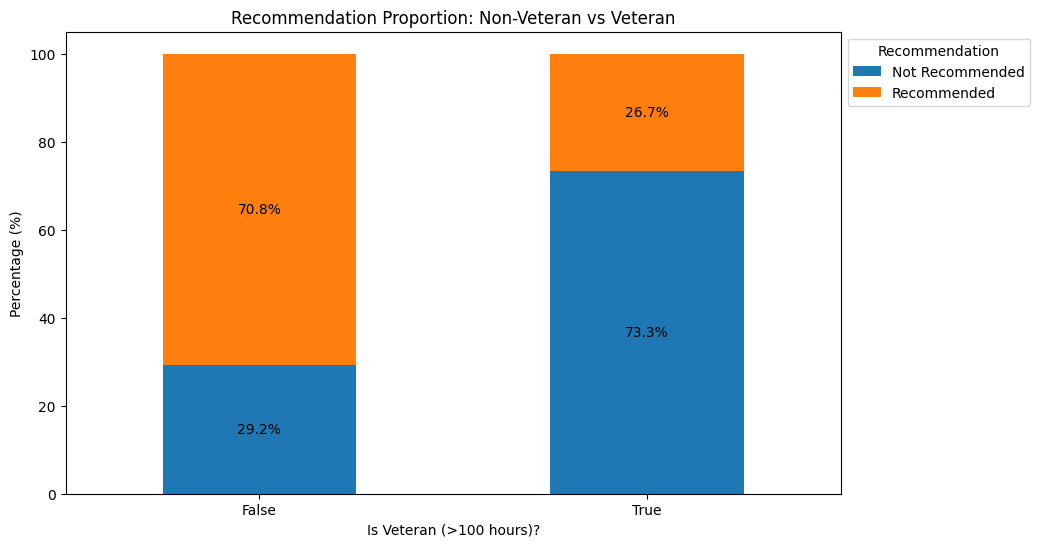


Counts: playtime_segment vs recommendation


recommendation,Not Recommended,Recommended
playtime_segment,,
Casual,5,9
Hardcore,4,1
New,0,3
Regular,2,5
Veteran,7,3



Percent within playtime segment:


recommendation,Not Recommended,Recommended
playtime_segment,,
Casual,35.71,64.29
Hardcore,80.00,20.00
New,0.00,100.00
Regular,28.57,71.43
Veteran,70.00,30.00


In [45]:
# Player segment analysis

# Check both raw counts and percentages.
# Percentages can be misleading without the raw counts, especially on a small dataset.

print("Counts: is_veteran vs recommendation")
display(
    pd.crosstab(
        df['is_veteran'],
        df['recommendation']
    )
)

print("\nPercent within veteran group:")
vet_crosstab_pct = (
    pd.crosstab(
        df['is_veteran'],
        df['recommendation'],
        normalize='index'
    ) * 100
).round(2)

display(vet_crosstab_pct)

ax = vet_crosstab_pct.plot(
    kind='bar',
    stacked=True
)

plt.title('Recommendation Proportion: Non-Veteran vs Veteran')
plt.ylabel('Percentage (%)')
plt.xlabel('Is Veteran (>100 hours)?')
plt.legend(title='Recommendation', loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.show()

if 'playtime_segment' in df.columns:
    print("\nCounts: playtime_segment vs recommendation")
    display(
        pd.crosstab(
            df['playtime_segment'],
            df['recommendation']
        )
    )

    print("\nPercent within playtime segment:")
    display(
        (
            pd.crosstab(
                df['playtime_segment'],
                df['recommendation'],
                normalize='index'
            ) * 100
        ).round(2)
    )

## 7. Review length analysis

This section checks whether negative reviews tend to be longer.

Longer negative reviews may indicate that dissatisfied players explain their complaints in more detail, while shorter reviews may contain simpler recommendations or jokes.

,count,mean,std,min,25%,50%,75%,max
recommendation,,,,,,,,
Not Recommended,18.0,134.611111,150.616825,1.0,20.5,80.5,166.0,490.0
Recommended,21.0,15.904762,14.703417,2.0,5.0,14.0,19.0,61.0



Average word count:


recommendation
Not Recommended    134.611111
Recommended         15.904762
Name: word_count, dtype: float64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_34600\3288294440.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


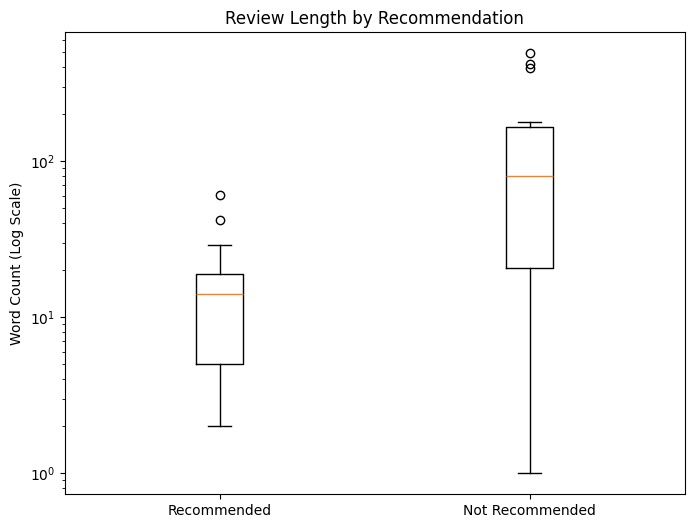

In [46]:
# Review length analysis

# Working question:
# Negative reviews may be longer because dissatisfied players often explain more issues.

review_length_summary = (
    df.groupby('recommendation')['word_count']
    .describe()
)

display(review_length_summary)

print("\nAverage word count:")
display(
    df.groupby('recommendation')['word_count']
    .mean()
)

# Boxplot visualization
# Filter word_count > 0 to avoid log-scale issues.
plot_df = df[df['word_count'] > 0].copy()

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        plot_df[
            plot_df['recommendation'] == 'Recommended'
        ]['word_count'],
        plot_df[
            plot_df['recommendation'] == 'Not Recommended'
        ]['word_count']
    ],
    labels=[
        'Recommended',
        'Not Recommended'
    ]
)

plt.yscale('log')
plt.title('Review Length by Recommendation')
plt.ylabel('Word Count (Log Scale)')
plt.show()

## 8. Refine keyword-based behavioral signals

The original dataset already contains some keyword flags, but this step refines them for EDA.

The refined flags are still heuristic.  
They are not final sentiment labels, but they help surface possible review themes such as updates, bugs, degradation, positive emotion, and negative emotion.

In [47]:
# Define keyword groups used to create exploratory review-theme flags.

UPDATE_KEYWORDS = [
    'update',
    'patch',
    'customization',
    'rework',
    'changed',
    'animation',
    'character',
    'cosmetic',
    'hotfix',
    'revert'
]

BUG_OR_DEGRADATION_KEYWORDS = [
    'bug',
    'glitch',
    'broken',
    'janky',
    'sluggish',
    'crash',
    'unplayable',
    'lag',
    'delay',
    'stutter',
    'stuttery',
    'motion sickness',
    'unusable',
    'underbaked',
    'softlocked',
    'animation locked',
    'mess',
    'jitter'
]

POSITIVE_EMOTION_KEYWORDS = [
    'great',
    'fun',
    'love',
    'awesome',
    'good',
    'amazing',
    'enjoy',
    'enjoying',
    'best'
]

NEGATIVE_EMOTION_KEYWORDS = [
    'ruined',
    'hate',
    'sad',
    'disappointed',
    'disappointing',
    'terrible',
    'awful',
    'mess',
    'broken',
    'regret',
    'shame',
    'boring',
    'bad'
]

def contains_any(text, keywords):
    text = str(text).lower()
    return any(keyword in text for keyword in keywords)

df['contains_update_keyword_refined'] = df['analysis_review'].apply(
    lambda x: contains_any(x, UPDATE_KEYWORDS)
)

df['contains_bug_or_degradation_keyword'] = df['analysis_review'].apply(
    lambda x: contains_any(x, BUG_OR_DEGRADATION_KEYWORDS)
)

df['contains_positive_emotion'] = df['analysis_review'].apply(
    lambda x: contains_any(x, POSITIVE_EMOTION_KEYWORDS)
)

df['contains_negative_emotion'] = df['analysis_review'].apply(
    lambda x: contains_any(x, NEGATIVE_EMOTION_KEYWORDS)
)

display(
    df[
        [
            'recommendation',
            'contains_update_keyword_refined',
            'contains_bug_or_degradation_keyword',
            'contains_positive_emotion',
            'contains_negative_emotion',
            'analysis_review'
        ]
    ].head()
)

,recommendation,contains_update_keyword_refined,contains_bug_or_degradation_keyword,contains_positive_emotion,contains_negative_emotion,analysis_review
0,Recommended,False,False,False,False,You can roast the ghost
1,Recommended,False,True,False,False,its an alright game but for me its too clumsy and a bit glitchy so i rarely play it.
2,Not Recommended,True,True,False,True,Rushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.
3,Recommended,False,False,False,False,I'm a lot less than just cleaning supplies and a lifeless bimbo body placed under a fabulous wig.
4,Recommended,False,False,True,False,"One of the best games i've played in a while. it scratches that curious itch for the unknown, and its fun to play when you're bored"


## 9. Update and bug/degradation keyword analysis

This section checks whether update-related and bug/degradation language appears differently across Steam recommendation labels.

If these keywords appear more often in `Not Recommended` reviews, they may help explain the source of player backlash.

In [48]:
print("Update keyword counts:")
display(
    pd.crosstab(
        df['contains_update_keyword_refined'],
        df['recommendation']
    )
)

print("\nUpdate keyword percentages:")
display(
    (
        pd.crosstab(
            df['contains_update_keyword_refined'],
            df['recommendation'],
            normalize='index'
        ) * 100
    ).round(2)
)

print("\nBug/degradation keyword counts:")
display(
    pd.crosstab(
        df['contains_bug_or_degradation_keyword'],
        df['recommendation']
    )
)

print("\nBug/degradation keyword percentages:")
display(
    (
        pd.crosstab(
            df['contains_bug_or_degradation_keyword'],
            df['recommendation'],
            normalize='index'
        ) * 100
    ).round(2)
)

Update keyword counts:


recommendation,Not Recommended,Recommended
contains_update_keyword_refined,,
False,3,18
True,15,3



Update keyword percentages:


recommendation,Not Recommended,Recommended
contains_update_keyword_refined,,
False,14.29,85.71
True,83.33,16.67



Bug/degradation keyword counts:


recommendation,Not Recommended,Recommended
contains_bug_or_degradation_keyword,,
False,6,18
True,12,3



Bug/degradation keyword percentages:


recommendation,Not Recommended,Recommended
contains_bug_or_degradation_keyword,,
False,25.0,75.0
True,80.0,20.0


## 10. Emotional language analysis

Instead of using one broad emotional flag, this step separates positive and negative emotional signals.

This helps identify whether emotional wording aligns with the Steam recommendation label or reveals more mixed behavior.

In [49]:
# Compare positive and negative emotion keyword signals against Steam recommendation labels.
print("Positive emotion keyword vs recommendation:")
display(
    pd.crosstab(
        df['contains_positive_emotion'],
        df['recommendation']
    )
)

display(
    (
        pd.crosstab(
            df['contains_positive_emotion'],
            df['recommendation'],
            normalize='index'
        ) * 100
    ).round(2)
)

print("\nNegative emotion keyword vs recommendation:")
display(
    pd.crosstab(
        df['contains_negative_emotion'],
        df['recommendation']
    )
)

display(
    (
        pd.crosstab(
            df['contains_negative_emotion'],
            df['recommendation'],
            normalize='index'
        ) * 100
    ).round(2)
)

Positive emotion keyword vs recommendation:


recommendation,Not Recommended,Recommended
contains_positive_emotion,,
False,7,8
True,11,13


recommendation,Not Recommended,Recommended
contains_positive_emotion,,
False,46.67,53.33
True,45.83,54.17



Negative emotion keyword vs recommendation:


recommendation,Not Recommended,Recommended
contains_negative_emotion,,
False,5,21
True,13,0


recommendation,Not Recommended,Recommended
contains_negative_emotion,,
False,19.23,80.77
True,100.00,0.00


## 11. Mourning behavior analysis

Some reviews may describe the game as something that used to be better.

This is useful because it captures a different kind of negativity: not just bugs, but nostalgia, loss, or disappointment with how the game changed over time.

In [50]:
# Detect reviews that frame the game as something that used to be better or has changed negatively.

MOURNING_KEYWORDS = [
    'used to love',
    'used to enjoy',
    'used to be fun',
    'used to be',
    'miss the old',
    'before the update',
    'was great until',
    'great until',
    'ruined the game',
    'they killed',
    'killed my',
    'bring back',
    'downhill',
    'no longer',
    'special charm',
    'revert'
]

df['is_mourning_refined'] = df['analysis_review'].apply(
    lambda x: contains_any(x, MOURNING_KEYWORDS)
)

print("Mourning vs recommendation counts:")
display(
    pd.crosstab(
        df['is_mourning_refined'],
        df['recommendation']
    )
)

print("\nMourning vs recommendation percentages:")
display(
    (
        pd.crosstab(
            df['is_mourning_refined'],
            df['recommendation'],
            normalize='index'
        ) * 100
    ).round(2)
)

print("\nExamples of mourning-like reviews:")
for text in (
    df[df['is_mourning_refined']]
    ['analysis_review']
    .head(5)
):
    print("-" * 80)
    print(text[:500])

Mourning vs recommendation counts:


recommendation,Not Recommended,Recommended
is_mourning_refined,,
False,12,21
True,6,0



Mourning vs recommendation percentages:


recommendation,Not Recommended,Recommended
is_mourning_refined,,
False,36.36,63.64
True,100.00,0.00



Examples of mourning-like reviews:
--------------------------------------------------------------------------------
this game was great until the character update please revert :D or at least fix all the issues its caused, like the delay on almost everything and the weird new animations.
--------------------------------------------------------------------------------
TLDR; New gamers, I urge you not to buy this game. Do not throw good money after bad. The majority of good reviews for this game are for an archived version of "Phasmophobia" which is longer exists and/or in not available after 05/05/26. After the debacle that is the 5/5 0.17 Cosmetics update, I dared hope that the devs might listen and fix the worst offenders in the follow-up hotfix of 12/05/26. This patch failed to address the core issues of "degraded visuals" (Avatars, animations, visual bugs
--------------------------------------------------------------------------------
This was a great game, an "indie" that made it 

## 12. Veteran players and mourning behavior

This section checks whether mourning-like reviews are more common among veteran or highly engaged players.

The idea is that players with more hours may have stronger attachment to earlier versions of the game.

is_veteran vs mourning counts:


is_mourning_refined,False,True
is_veteran,,
False,24,0
True,9,6



is_veteran vs mourning percentages:


is_mourning_refined,False,True
is_veteran,,
False,100.0,0.0
True,60.0,40.0



playtime_segment vs mourning percentages:


is_mourning_refined,False,True
playtime_segment,,
Casual,100.0,0.0
Hardcore,80.0,20.0
New,100.0,0.0
Regular,100.0,0.0
Veteran,50.0,50.0


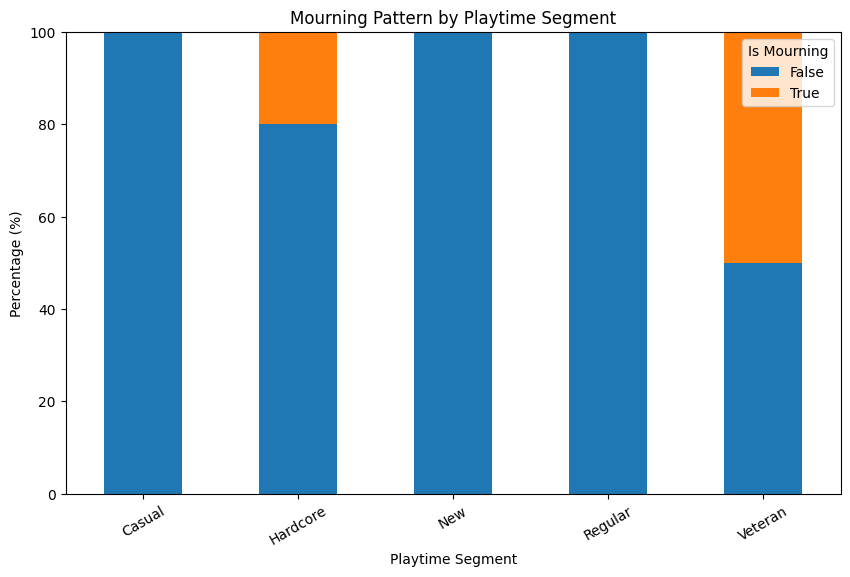

In [51]:
print("is_veteran vs mourning counts:")
display(
    pd.crosstab(
        df['is_veteran'],
        df['is_mourning_refined']
    )
)

print("\nis_veteran vs mourning percentages:")
display(
    (
        pd.crosstab(
            df['is_veteran'],
            df['is_mourning_refined'],
            normalize='index'
        ) * 100
    ).round(2)
)

if 'playtime_segment' in df.columns:
    print("\nplaytime_segment vs mourning percentages:")
    mourning_segment_pct = (
        pd.crosstab(
            df['playtime_segment'],
            df['is_mourning_refined'],
            normalize='index'
        ) * 100
    ).round(2)

    display(mourning_segment_pct)

    mourning_segment_pct.plot(
        kind='bar',
        stacked=True
    )

    plt.title('Mourning Pattern by Playtime Segment')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Playtime Segment')
    plt.xticks(rotation=30)
    plt.legend(title='Is Mourning')
    plt.show()

## 13. Detect possible mismatch candidates

A mismatch candidate is a `Recommended` review where the text still contains complaint signals.

This is an early operational definition, not the final label.  
The goal is to identify reviews that may need manual inspection because the Steam label and review text may not tell the same simple story.

In [52]:
# Mark Recommended reviews that still contain update, bug/degradation, or negative emotion signals.

df['is_mismatch_candidate'] = (
    (df['recommendation'] == 'Recommended')
    &
    (
        df['contains_bug_or_degradation_keyword']
        |
        df['contains_update_keyword_refined']
        |
        df['contains_negative_emotion']
    )
    &
    (df['word_count'] > 10)
)

mismatch_candidates = df[df['is_mismatch_candidate']].copy()

print(f"Mismatch candidates found: {len(mismatch_candidates)}")

display(
    mismatch_candidates[
        [
            'playtime_hours',
            'word_count',
            'helpful_count',
            'funny_count',
            'contains_update_keyword_refined',
            'contains_bug_or_degradation_keyword',
            'contains_negative_emotion',
            'analysis_review'
        ]
    ].head(10)
)

Mismatch candidates found: 4


,playtime_hours,word_count,helpful_count,funny_count,contains_update_keyword_refined,contains_bug_or_degradation_keyword,contains_negative_emotion,analysis_review
1,72.7,19,0,0,False,True,False,its an alright game but for me its too clumsy and a bit glitchy so i rarely play it.
8,25.6,61,0,0,True,True,False,"I'm really enjoying this new update. The diner map is super fun and has a great, creepy vibe. Some people are hating on the update, i might be missing something, but so far everything is awesome. The only real issue I've seen is the fridge door glitching; it bugs out sometimes, but it hasn't sto..."
10,37.1,14,0,0,True,True,False,amazing game. 10/10. they do need to fix the bugs with the new update
19,33.9,14,0,0,True,False,False,"great game, some players are so whiny about update ""waaah waaah its slow waaah"""


## 14. Engagement signals

This section checks whether mismatch candidates are associated with helpful or funny votes.

Because the sample is small, this is only exploratory, but it can still show whether ambiguous or complaint-heavy reviews receive more visible community interaction.

,helpful_count,funny_count,word_count,playtime_hours
is_mismatch_candidate,,,,
False,1.628571,0.114286,75.685714,154.888571
True,0.000000,0.000000,27.000000,42.325000


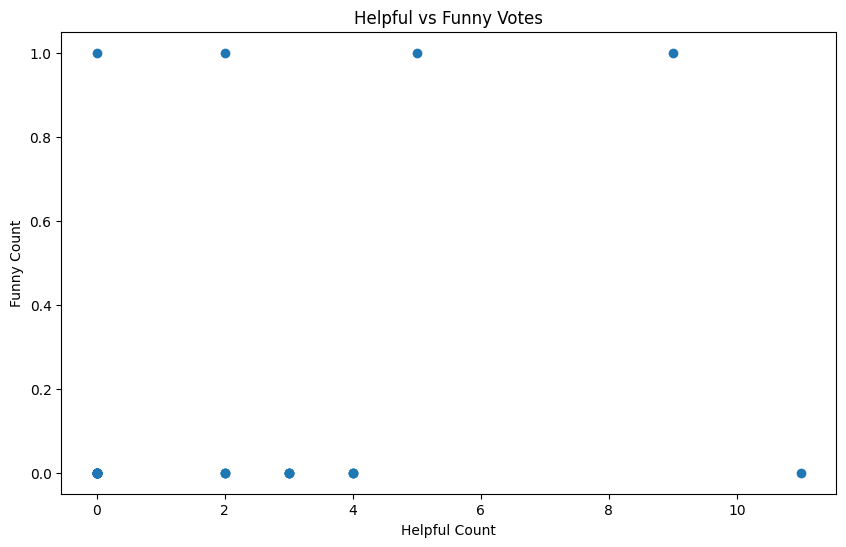

In [53]:
# Compare engagement signals between mismatch candidates and other reviews.

engagement_summary = (
    df.groupby('is_mismatch_candidate')
    [
        [
            'helpful_count',
            'funny_count',
            'word_count',
            'playtime_hours'
        ]
    ]
    .mean()
)

display(engagement_summary)

plt.scatter(
    df['helpful_count'],
    df['funny_count']
)

plt.title('Helpful vs Funny Votes')
plt.xlabel('Helpful Count')
plt.ylabel('Funny Count')
plt.show()

## 15. Playtime vs review length

This scatter plot checks whether higher playtime is associated with longer reviews.

This helps connect player experience level with how much detail players write when giving feedback.

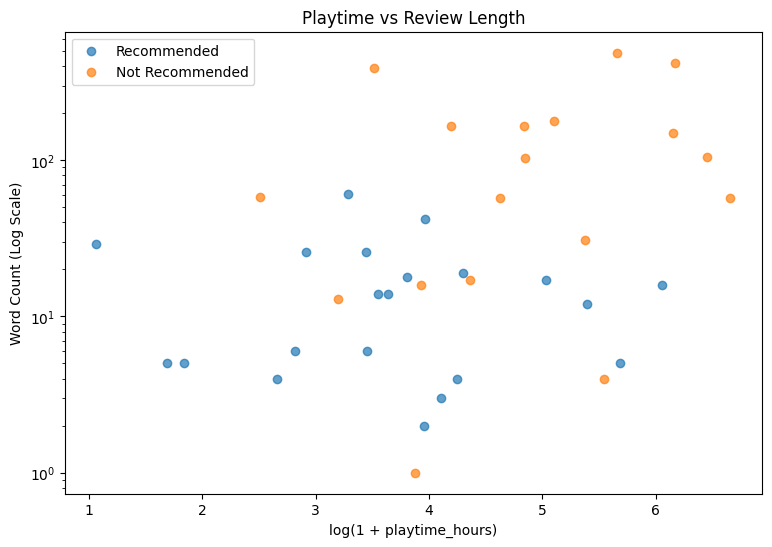

,recommendation,playtime_hours,word_count,analysis_review
17,Not Recommended,286.1,490,"TLDR; New gamers, I urge you not to buy this game. Do not throw good money after bad. The majority of good reviews for this game are for an archived version of ""Phasmophobia"" which is longer exists and/or in not available after 05/05/26. After the debacle that is the 5/5 0.17 Cosmetics update, I..."
12,Not Recommended,476.6,418,"I used to really love playing this game, but it seems the devs have just been making questionable decisions ever since the item update. Rather than rework maps that no one likes, like school or prison, they reworked a beloved map. I actually like new Tanglewood, but it feels like they only did t..."
39,Not Recommended,32.7,393,"Super disappointed at the new update. I've been playing this game religiously with my friends before it went to buns. The 'character customization' is just a preset of character models, you can't actually customize the skin, hair, face, etc. There's barely any clothing and most of the accessorie..."
37,Not Recommended,162.8,179,So were supposed to get character customization and yet we only got a bunch of random assets thrown together. The game has been out for over a half a decade and yet it feels more and more early access as more updates gets out. just revert back to the old update with the old characters and old ma...
22,Not Recommended,65.4,166,This last update was a mess. It's been on the roadmap since 2022 yet the devs keep saying it was rushed at every turn. An update that is a flawed mess of so called features. If you like awful AI like animations and a dev team that will lie about the poor quality of updates and then deflect when ...
38,Not Recommended,125.5,166,"Phas had a special jankyness that brought a little charm to the game. Only thing they ever needed to fix was loading screen bugs and ghosts not functioning properly. The community asks for workshop or for more maps that make sense at the very least, just a few character customization options, mo..."
16,Not Recommended,470.5,149,"TL;DR Don't get it yet character customization added animations that made it so sluggish I have played this game for many hours, maybe not as much as some of the community but still enough to enjoy my time with this game, I have been through the janky times of when the game first came out and I ..."
27,Not Recommended,630.3,105,"Boycott until the jank is fixed. They company has made 2 million some odd dollars from this game, early access( 6 years) , lack lustre updates that take months at a time and when we do get the updates they are broken, shallow or just plain boring . Idk what happened to the phasmo of yore but som..."
15,Not Recommended,126.2,103,"The ""Player Character Update 0.17.0.0"" has shown that the dev team desperately needs to sit down and review their development and testing processes. There have been multiple minor issues with updates over the games lifetime, but this update in particular has been a horrendous display of complace..."
8,Recommended,25.6,61,"I'm really enjoying this new update. The diner map is super fun and has a great, creepy vibe. Some people are hating on the update, i might be missing something, but so far everything is awesome. The only real issue I've seen is the fridge door glitching; it bugs out sometimes, but it hasn't sto..."


In [54]:
plt.figure(figsize=(9, 6))

for label in df['recommendation'].dropna().unique():
    subset = df[df['recommendation'] == label]

    plt.scatter(
        subset['log_playtime'],
        subset['word_count'],
        label=label,
        alpha=0.7
    )

plt.yscale('log')
plt.title('Playtime vs Review Length')
plt.xlabel('log(1 + playtime_hours)')
plt.ylabel('Word Count (Log Scale)')
plt.legend()
plt.show()

display(
    df[
        [
            'recommendation',
            'playtime_hours',
            'word_count',
            'analysis_review'
        ]
    ]
    .sort_values('word_count', ascending=False)
    .head(10)
)

## Preliminary Findings

### 1. Veteran Backlash

Early results suggest that veteran players may be more likely to leave negative recommendations.

This may reflect stronger emotional investment, higher expectations, or resistance toward gameplay changes.

---

### 2. Review Length and Emotional Expression

Negative reviews appear longer on average, suggesting that dissatisfied players may provide more detailed complaints.

This does not prove emotion by itself, but it gives a useful behavioral signal.

---

### 3. Update / Bug / Degradation Discussion

Reviews mentioning updates, bugs, or gameplay degradation appear closely related to negative recommendations.

This supports the idea that player backlash may be tied to perceived quality decline after updates.

---

### 4. Mourning Behavior

Some negative reviews show nostalgia, loss, or betrayal framing.

This is useful because the review is not only negative, but also emotionally attached to an older version of the game.

## Limitations

These findings should still be treated as exploratory.

Current limitations:

- The sample size is small.
- Keyword-based features can produce false positives and false negatives.
- Sarcasm and mixed sentiment are difficult to detect without manual tagging.
- Steam recommendation labels are not the same as actual sentiment.
- Review dates are not fully normalized into complete timestamps.
- The dataset may be biased toward the specific update period captured during scraping.

These limitations should be mentioned in the project report or portfolio write-up.

## 16. Export manual tagging candidates

After the EDA, the notebook exports a candidate set for manual annotation.

The sample intentionally combines several groups:

- negative reviews
- positive-looking reviews
- mismatch candidates
- mourning-like reviews
- reviews with helpful or funny engagement

This output is saved to `data/interim/` because it is a preparation file, not a final processed dataset.

In [55]:
# Create a diverse candidate set for manual annotation.

def safe_sample(dataframe, n=20, random_state=42):
    if len(dataframe) == 0:
        return dataframe.copy()

    return dataframe.sample(
        min(n, len(dataframe)),
        random_state=random_state
    )

# Candidate groups for manual inspection.
negative_reviews = df[
    df['recommendation'] == 'Not Recommended'
]

positive_clean_reviews = df[
    (df['recommendation'] == 'Recommended')
    &
    (~df['contains_bug_or_degradation_keyword'])
    &
    (~df['contains_negative_emotion'])
    &
    (df['word_count'] > 2)
]

mismatch_reviews = df[
    df['is_mismatch_candidate']
]

mourning_reviews = df[
    df['is_mourning_refined']
]

high_engagement_reviews = df[
    (df['helpful_count'] > 0)
    |
    (df['funny_count'] > 0)
]

# Sample each group so the tagging file contains varied review patterns.
sample_neg = safe_sample(negative_reviews, n=20, random_state=42)
sample_pos = safe_sample(positive_clean_reviews, n=20, random_state=43)
sample_mismatch = safe_sample(mismatch_reviews, n=20, random_state=44)
sample_mourning = safe_sample(mourning_reviews, n=10, random_state=45)
sample_engagement = safe_sample(high_engagement_reviews, n=10, random_state=46)

manual_tagging_df = pd.concat(
    [
        sample_neg,
        sample_pos,
        sample_mismatch,
        sample_mourning,
        sample_engagement
    ],
    ignore_index=True
).drop_duplicates(
    subset=['analysis_review']
)

# Empty columns to be filled during manual annotation.
manual_tagging_df['actual_sentiment'] = ''
manual_tagging_df['review_category'] = ''
manual_tagging_df['annotation_notes'] = ''

export_columns = [
    'game_title',
    'author_name',
    'review_date',
    'recommendation',
    'playtime_hours',
    'playtime_segment',
    'is_veteran',
    'word_count',
    'helpful_count',
    'funny_count',
    'contains_update_keyword_refined',
    'contains_bug_or_degradation_keyword',
    'contains_positive_emotion',
    'contains_negative_emotion',
    'is_mourning_refined',
    'is_mismatch_candidate',
    'analysis_review',
    'actual_sentiment',
    'review_category',
    'annotation_notes'
]

available_export_columns = [
    col for col in export_columns
    if col in manual_tagging_df.columns
]

output_path = DATA_INTERIM / 'manual_tagging_candidates.csv'

manual_tagging_df[
    available_export_columns
].to_csv(
    output_path,
    index=False
)

print(f"Saved manual tagging candidates to: {output_path}")
print(f"Rows exported: {len(manual_tagging_df)}")

display(
    manual_tagging_df[
        available_export_columns
    ].head(10)
)


Saved manual tagging candidates to: ..\data\interim\manual_tagging_candidates.csv
Rows exported: 38


,game_title,author_name,review_date,recommendation,playtime_hours,playtime_segment,is_veteran,word_count,helpful_count,funny_count,contains_update_keyword_refined,contains_bug_or_degradation_keyword,contains_positive_emotion,contains_negative_emotion,is_mourning_refined,is_mismatch_candidate,analysis_review,actual_sentiment,review_category,annotation_notes
0,Phasmophobia,Clown,Posted: 12 May,Not Recommended,77.1,Regular,False,17,0,0,True,True,False,True,False,False,Rushed out a buggy and broken update so they could do an Alan Wake (2) collab. Marvelous.,,,
1,Phasmophobia,Eggis,Posted: 12 May,Not Recommended,23.5,Casual,False,13,3,0,True,False,False,True,False,False,The latest update has ruined the experience for me ( bendy back gone),,,
2,Phasmophobia,Tracker,Posted: May 12,Not Recommended,65.4,Regular,False,166,4,0,True,True,True,True,False,False,This last update was a mess. It's been on the roadmap since 2022 yet the devs keep saying it was rushed at every turn. An update that is a flawed mess of so called features. If you like awful AI like animations and a dev team that will lie about the poor quality of updates and then deflect when ...,,,
3,Phasmophobia,King Chonk,Posted: May 12,Not Recommended,470.5,Hardcore,True,149,0,0,True,True,True,True,False,False,"TL;DR Don't get it yet character customization added animations that made it so sluggish I have played this game for many hours, maybe not as much as some of the community but still enough to enjoy my time with this game, I have been through the janky times of when the game first came out and I ...",,,
4,Phasmophobia,Scout,Posted: May 12,Not Recommended,476.6,Hardcore,True,418,3,0,True,True,True,True,False,False,"I used to really love playing this game, but it seems the devs have just been making questionable decisions ever since the item update. Rather than rework maps that no one likes, like school or prison, they reworked a beloved map. I actually like new Tanglewood, but it feels like they only did t...",,,
5,Phasmophobia,Biker,Posted: May 12,Not Recommended,50.0,Casual,False,16,9,1,False,False,False,False,False,False,"6 years and tons of money yet they can't get this game right, Utter clown devs.",,,
6,Phasmophobia,Milk,Posted: May 12,Not Recommended,125.5,Veteran,True,166,3,0,True,True,True,True,True,False,"Phas had a special jankyness that brought a little charm to the game. Only thing they ever needed to fix was loading screen bugs and ghosts not functioning properly. The community asks for workshop or for more maps that make sense at the very least, just a few character customization options, mo...",,,
7,Phasmophobia,Jona,Posted: May 12,Not Recommended,162.8,Veteran,True,179,5,1,True,False,True,False,True,False,So were supposed to get character customization and yet we only got a bunch of random assets thrown together. The game has been out for over a half a decade and yet it feels more and more early access as more updates gets out. just revert back to the old update with the old characters and old ma...,,,
8,Phasmophobia,mr•step,Posted: May 12,Not Recommended,777.7,Hardcore,True,57,3,0,True,True,True,True,True,False,"This was a great game, an ""indie"" that made it big. The last update(s) have made it virtually unplayable. The UI is virtually unusable, the performance is now a stuttery mess, and all the ""indie janky charm"" has been replaced by ""failed realism"". 700+ hours in game, and I no longer recommend it ...",,,
9,Phasmophobia,impulse,Posted: 12 May,Not Recommended,215.6,Veteran,True,31,0,0,True,True,True,False,True,False,"this game was great until the character update please revert :D or at least fix all the issues its caused, like the delay on almost everything and the weird new animations.",,,


In [56]:
manual_tagging_df.shape

(38, 30)

## Next Step After This Notebook

After finishing this EDA notebook, the next phase is **manual tagging**.

Recommended flow:

1. Open `manual_tagging_candidates.csv`.
2. Fill these columns manually:
   - `actual_sentiment`
   - `review_category`
   - `annotation_notes`
3. Use clear labeling rules.
4. After tagging, create a new notebook:

```text
notebooks/03_sentiment_mismatch_analysis.ipynb
```

The purpose of the next notebook is to compare:

```text
Steam recommendation label
vs
Human-labeled actual sentiment
```

This is where the core project thesis becomes visible:

> Do Steam recommendation labels actually match what players express in review text?